LongBench-E HotpotQA example
        ↓
same ID as Notebook 03
        ↓
gold answer
        ↓
first gold-answer token
        ↓
run prompt through AHN
        ↓
capture memory contribution at layers 9, 18, 27
        ↓
J-Lens/logit readout exactly like Notebook 04
        ↓
measure:
    target rank
    target probability
    entropy
        ↓
join Notebook 03:
    delta_f1_fl
    delta_f1
    stratum
        ↓
save
04b_joined_retention_task.json

In [1]:
   import os
   os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [2]:
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("Visible GPUs:", torch.cuda.device_count())

free, total = torch.cuda.mem_get_info()
print(f"Free VRAM: {free / 1024**3:.1f} GB / {total / 1024**3:.1f} GB")

GPU: NVIDIA A100-SXM4-40GB
Visible GPUs: 1
Free VRAM: 39.1 GB / 39.5 GB


In [3]:
!nvidia-smi

Thu Aug 20 18:33:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:10:1C.0 Off |                    0 |
| N/A   75C    P0            348W /  400W |   40057MiB /  40960MiB |     98%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
import json

with open("../results/run_3b_gdn/03_nowrite_reproduction.json", "r") as f:
    rq1 = json.load(f)

results_03 = rq1["per_example"]

print("Number of examples:", len(results_03))

Number of examples: 60


In [5]:
from datasets import load_dataset

ds = load_dataset(
    "THUDM/LongBench",
    "hotpotqa_e",
    split="test"
)

print("Total LongBench-E HotpotQA examples:", len(ds))

Total LongBench-E HotpotQA examples: 300


In [6]:
wanted_ids = {str(r["id"]) for r in results_03}

examples_04b = [
    ex for ex in ds
    if str(ex["_id"]) in wanted_ids
]

print("Found:", len(examples_04b), "of", len(wanted_ids))

Found: 60 of 60


In [7]:
ex = examples_04b[0]

print("ID:", ex["_id"])
print("QUESTION:", ex["input"])
print("GOLD ANSWER:", ex["answers"])

ID: 36b7e445832590b8ddf74995162cd5e94f7f620cdfc992dd
QUESTION: What is the weight limit of the weight class that Takeyasu Hirono fights in?
GOLD ANSWER: ['125 lb (57 kg)']


In [11]:
import sys
import os
import json

sys.path.insert(0, "..")

import ahn_interp as ai

CFG = dict(
    model_path="/home/jupyter-dphs-4ca1/AHN/merged_ckpt/Qwen-2.5-Instruct-3B-AHN-GDN",
    cell="GatedDeltaNet",
    scale="3B",
    sliding_window=8064,
    num_attn_sinks=128,
    attn_impl="flash_attention_2",
    dtype="bfloat16",
    results_dir="../results/run_3b_gdn",
)

EXP = dict(
    layers=[9, 18, 27],
    use_jlens=True,
    jlens_path="../results/run_3b_gdn/jlens_qwen25_3b.pt",
)

print("Configuration ready")

Configuration ready


In [12]:
import torch
import numpy as np
import time

# Tell ahn_interp where the result files are
ai.set_results_dir(CFG["results_dir"])

# Load the AHN model
bundle = ai.load_ahn_model(
    CFG["model_path"],
    dtype=getattr(torch, CFG["dtype"]),
    attn_implementation=CFG["attn_impl"],
    sliding_window=CFG["sliding_window"],
    num_attn_sinks=CFG["num_attn_sinks"],
)

tok = bundle.tokenizer
probe = ai.AHNProbe(bundle)

print("Model loaded successfully")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded successfully


In [13]:
gold_answer = ex["answers"][0]

token_ids = tok.encode(
    gold_answer,
    add_special_tokens=False
)

target_token_id = token_ids[0]

print("Gold answer:", gold_answer)
print("Token IDs:", token_ids)
print("Target token ID:", target_token_id)
print("Target token text:", repr(tok.decode([target_token_id])))

Gold answer: 125 lb (57 kg)
Token IDs: [16, 17, 20, 18866, 320, 20, 22, 20972, 8]
Target token ID: 16
Target token text: '1'


In [14]:
lens = ai.JacobianLens.load(
    EXP["jlens_path"],
    map_location=str(bundle.model.device)
)

print("J-lens loaded")
print("Available layers:", sorted(lens.jacobians))

J-lens loaded
Available layers: [9, 18, 27]


In [15]:
# Rebuild the exact Notebook 03 prompt for this example
prompt_tmpl = (
    "Answer the question based on the given passages. Only give me the answer and do "
    "not output any other words.\n\nThe following are given passages.\n{context}\n\n"
    "Answer the question based on the given passages. Only give me the answer and do "
    "not output any other words.\n\nQuestion: {input}\nAnswer:"
)

prompt = prompt_tmpl.format(
    context=ex["context"],
    input=ex["input"]
)

input_ids = tok(
    prompt,
    return_tensors="pt",
    add_special_tokens=True
).input_ids.to(bundle.model.device)

print("Input tokens:", input_ids.shape[1])
print("Target:", repr(tok.decode([target_token_id])))

Input tokens: 10674
Target: '1'


In [17]:
# Run ONE LongBench example through AHN and inspect memory

ins = tok(
    prompt,
    return_tensors="pt"
).to(bundle.model.device)

with torch.no_grad():
    on = probe.run(
        ins,
        nowrite=False,
        layers=EXP["layers"],
        capture_residual=True
    )

print("Captured AHN layers:", sorted(on.ahn_raw.keys()))

Captured AHN layers: [9, 18, 27]


In [18]:
layer = 18

# AHN memory contribution at the final token position
memory_vec = on.o_t(layer)

# Decode that memory vector with the J-Lens
logits = ai.readout_logits(
    memory_vec,
    bundle,
    lens=lens,
    layer=layer
)

# Convert to probabilities
probs = torch.softmax(logits.float(), dim=-1)

# Rank of the correct target token
target_logit = logits[target_token_id]
rank = int((logits > target_logit).sum().item())

target_prob = float(probs[target_token_id].item())

print("Layer:", layer)
print("Target token:", repr(tok.decode([target_token_id])))
print("Target rank:", rank)
print("Target probability:", target_prob)

Layer: 18
Target token: '1'
Target rank: 150768
Target probability: 5.776824919022922e-17


In [23]:
for layer in [9, 18, 27]:

    memory_vec = on.o_t(layer)

    logits = ai.readout_logits(
        memory_vec,
        bundle,
        lens=lens,
        layer=layer
    )

    probs = torch.softmax(logits.float(), dim=-1)

    target_logit = logits[target_token_id]
    rank = int((logits > target_logit).sum().item())
    target_prob = float(probs[target_token_id].item())

    print(
        "Layer:", layer,
        "| Target:", repr(tok.decode([target_token_id])),
        "| Rank:", rank,
        "| Probability:", target_prob
    )

Layer: 9 | Target: '1' | Rank: 3656 | Probability: 5.576213106399622e-18
Layer: 18 | Target: '1' | Rank: 150768 | Probability: 5.776824919022922e-17
Layer: 27 | Target: '1' | Rank: 61675 | Probability: 2.0088927499273268e-07


The memory had some signal for the correct answer token, but AHN did not improve the final answer on this example.

In [22]:
print("ID:", result_03["id"])
print("Gold:", result_03["gold"])

print("AHN answer:", result_03["answer_ahn_fl"])
print("NOWRITE answer:", result_03["answer_nowrite_fl"])

print("AHN F1:", result_03["f1_ahn_fl"])
print("NOWRITE F1:", result_03["f1_nowrite_fl"])

print("delta_f1_fl:", result_03["delta_f1_fl"])

ID: 36b7e445832590b8ddf74995162cd5e94f7f620cdfc992dd
Gold: ['125 lb (57 kg)']
AHN answer: 125 lb (57 kg)
NOWRITE answer: 125 lb 57 kg
AHN F1: 1.0
NOWRITE F1: 1.0
delta_f1_fl: 0.0


Run on 60 examples

In [24]:
import json
import math
import torch
from pathlib import Path

OUT_PATH = Path("../results/run_3b_gdn/04b_joined_retention_task.json")

# Match Notebook 03 results by ID
result_by_id = {str(r["id"]): r for r in results_03}

rows = []

prompt_tmpl = (
    "Answer the question based on the given passages. Only give me the answer and do "
    "not output any other words.\n\nThe following are given passages.\n{context}\n\n"
    "Answer the question based on the given passages. Only give me the answer and do "
    "not output any other words.\n\nQuestion: {input}\nAnswer:"
)

for i, ex in enumerate(examples_04b, start=1):

    ex_id = str(ex["_id"])
    r03 = result_by_id[ex_id]

    # Correct answer
    gold_answer = ex["answers"][0]

    # First token of correct answer
    token_ids = tok.encode(gold_answer, add_special_tokens=False)

    if len(token_ids) == 0:
        print(f"[{i}/60] SKIP: empty tokenization {ex_id}")
        continue

    target_token_id = token_ids[0]
    target_token_text = tok.decode([target_token_id])

    # Rebuild EXACT Notebook 03 prompt
    prompt = prompt_tmpl.format(
        context=ex["context"],
        input=ex["input"]
    )

    ins = tok(
        prompt,
        return_tensors="pt"
    ).to(bundle.model.device)

    # Run model once and capture AHN at all 3 layers
    with torch.no_grad():
        on = probe.run(
            ins,
            nowrite=False,
            layers=EXP["layers"],
            capture_residual=True
        )

    layer_metrics = {}

    for layer in EXP["layers"]:

        memory_vec = on.o_t(layer)

        logits = ai.readout_logits(
            memory_vec,
            bundle,
            lens=lens,
            layer=layer
        )

        logits = logits.float()
        probs = torch.softmax(logits, dim=-1)

        target_logit = logits[target_token_id]

        rank = int((logits > target_logit).sum().item())
        p_mem = float(probs[target_token_id].item())

        # Entropy of full vocabulary distribution
        entropy = float(
            -(probs * torch.log(probs.clamp_min(1e-30))).sum().item()
        )

        layer_metrics[str(layer)] = {
            "rank": rank,
            "p_mem": p_mem,
            "entropy": entropy,
        }

    # For now use layer 18 as the fixed RQ3 summary layer
    # We still save all 3 layers so nothing is lost.
    main_layer = 18
    m = layer_metrics[str(main_layer)]

    row = {
        "id": ex_id,
        "cell": CFG["cell"],
        "scale": CFG["scale"],
        "stratum": r03["stratum"],

        "n_tokens": r03["n_tokens"],

        "gold": gold_answer,
        "target_token_id": int(target_token_id),
        "target_token_text": target_token_text,

        # Primary corrected Notebook 03 outcome
        "delta_f1": float(r03["delta_f1_fl"]),

        # Keep original too
        "delta_f1_full_generation": float(r03["delta_f1"]),

        "f1_ahn": float(r03["f1_ahn_fl"]),
        "f1_nowrite": float(r03["f1_nowrite_fl"]),

        "readout": "jlens",
        "summary_layer": main_layer,

        # Notebook 05 expects these names
        "rank_at_prompt_end": m["rank"],
        "p_mem_at_prompt_end": m["p_mem"],
        "entropy_at_prompt_end": m["entropy"],
        # We do NOT have a per-example half-life from this single task prompt.
        "half_life": None,

        # Preserve all layers
        "layers": layer_metrics,
    }

    rows.append(row)

    # Save after EVERY example
    payload = {
        "n": len(rows),
        "cell": CFG["cell"],
        "scale": CFG["scale"],
        "summary_layer": main_layer,
        "rows": rows,
    }

    with open(OUT_PATH, "w") as f:
        json.dump(payload, f, indent=2)

    print(
        f"[{i:02d}/60] "
        f"{gold_answer!r} | "
        f"target={target_token_text!r} | "
        f"L18 rank={m['rank']} | "
        f"dF1={r03['delta_f1_fl']:+.3f}"
    )

    # Release per-example tensors
    del ins, on, memory_vec, logits, probs
    torch.cuda.empty_cache()

print("\nDONE")
print("Saved:", OUT_PATH)
print("Rows:", len(rows))

[01/60] '125 lb (57 kg)' | target='1' | L18 rank=150768 | dF1=+0.000
[02/60] 'Istanbul, Turkey' | target='I' | L18 rank=139374 | dF1=+0.000
[03/60] 'no' | target='no' | L18 rank=77645 | dF1=+0.000
[04/60] 'yes' | target='yes' | L18 rank=49483 | dF1=+0.000
[05/60] 'Dallas Cowboys' | target='Dallas' | L18 rank=65054 | dF1=+0.000
[06/60] 'pale lager' | target='p' | L18 rank=115118 | dF1=+0.500
[07/60] 'Aloe Vera of America' | target='A' | L18 rank=96618 | dF1=+0.000
[08/60] 'June 17, 2007' | target='June' | L18 rank=124900 | dF1=+0.000
[09/60] '1976' | target='1' | L18 rank=141553 | dF1=+0.000
[10/60] 'Newfoundland and Labrador' | target='New' | L18 rank=126632 | dF1=+0.333
[11/60] 'Democratic' | target='Democratic' | L18 rank=105768 | dF1=+0.000
[12/60] 'Tie Domi' | target='T' | L18 rank=139066 | dF1=+0.000
[13/60] 'novel' | target='nov' | L18 rank=121115 | dF1=+0.000
[14/60] 'Ellie Kemper' | target='Ell' | L18 rank=49314 | dF1=+0.000
[15/60] 'Gregory Walter Graffin' | target='Greg' | L1

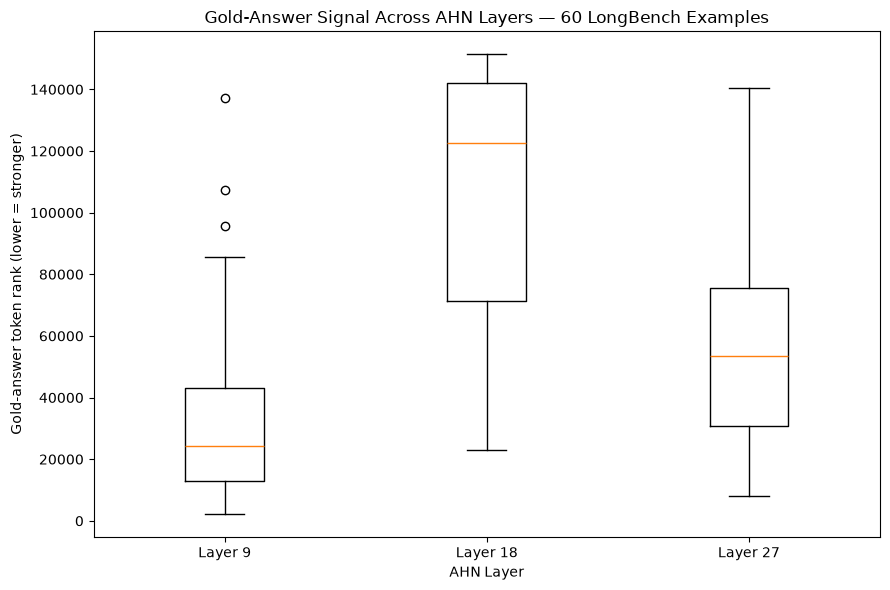

Layer 9: median rank = 24,372, mean rank = 33,230
Layer 18: median rank = 122,671, mean rank = 108,049
Layer 27: median rank = 53,528, mean rank = 58,720


In [26]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open("../results/run_3b_gdn/04b_joined_retention_task.json") as f:
    data = json.load(f)

rows = data["rows"]

layers = [9, 18, 27]

# Get target-token rank for every example at each layer
rank_data = [
    [r["layers"][str(layer)]["rank"] for r in rows]
    for layer in layers
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    rank_data,
    tick_labels=[f"Layer {l}" for l in layers],
    showfliers=True
)

plt.ylabel("Gold-answer token rank (lower = stronger)")
plt.xlabel("AHN Layer")
plt.title("Gold-Answer Signal Across AHN Layers — 60 LongBench Examples")

plt.tight_layout()
plt.show()

# Also print median rank
for layer, ranks in zip(layers, rank_data):
    print(
        f"Layer {layer}: "
        f"median rank = {np.median(ranks):,.0f}, "
        f"mean rank = {np.mean(ranks):,.0f}"
    )

The original code used Layer 18 as the RQ3 summary layer without a clear justification. I checked all three layers instead. Spearman results were:

Layer 9: ρ = +0.257, p = 0.0471
Layer 18: ρ = −0.100, p = 0.4484
Layer 27: ρ = +0.020, p = 0.8796
Layer 9 is only borderline and is in the opposite direction we might expect because lower rank means stronger decodability. We still need multiple-comparison correction / confidence intervals before interpreting it.

In [30]:
from scipy.stats import spearmanr

for layer in [9, 18, 27]:
    ranks = [
        r["layers"][str(layer)]["rank"]
        for r in rows
    ]

    df1 = [
        r["delta_f1"]
        for r in rows
    ]

    rho, p = spearmanr(ranks, df1)

    print(
        f"Layer {layer}: "
        f"rho={rho:.3f}, p={p:.4f}"
    )

Layer 9: rho=0.257, p=0.0471
Layer 18: rho=-0.100, p=0.4484
Layer 27: rho=0.020, p=0.8796


### RQ3 Preliminary Results

We do not have strong enough evidence that **gold first-token memory rank is related to AHN's improvement in F1** at any of the three tested layers.

- **Layer 9:** ρ = 0.257, p = 0.047, 95% bootstrap CI = [-0.015, 0.487]
- **Layer 18:** ρ = -0.100, p = 0.448, 95% bootstrap CI = [-0.316, 0.119]
- **Layer 27:** ρ = 0.020, p = 0.880, 95% bootstrap CI = [-0.213, 0.240]

Although Layer 9 showed a weak positive correlation, its 95% confidence interval crosses zero. Therefore, this relationship is **not robust enough to treat as a reliable finding**.

Layers 18 and 27 also showed no robust relationship between gold first-token J-Lens rank and ΔF1.

**Current conclusion:** No robust correlation was found between gold first-token J-Lens rank and ΔF1 across the three tested layers.

In [31]:
import numpy as np
from scipy.stats import spearmanr

rng = np.random.default_rng(20260820)

def bootstrap_spearman(x, y, n_boot=5000):
    x = np.asarray(x)
    y = np.asarray(y)

    boot_rhos = []

    for _ in range(n_boot):
        # Randomly resample the 60 examples
        idx = rng.integers(0, len(x), len(x))

        rho = spearmanr(x[idx], y[idx]).statistic

        if np.isfinite(rho):
            boot_rhos.append(rho)

    boot_rhos = np.asarray(boot_rhos)

    original_rho = spearmanr(x, y).statistic

    ci_low = np.percentile(boot_rhos, 2.5)
    ci_high = np.percentile(boot_rhos, 97.5)

    return original_rho, ci_low, ci_high


for layer in [9, 18, 27]:

    ranks = [
        r["layers"][str(layer)]["rank"]
        for r in rows
    ]

    df1 = [
        r["delta_f1"]
        for r in rows
    ]

    rho, low, high = bootstrap_spearman(ranks, df1)

    print(
        f"Layer {layer}: "
        f"rho={rho:.3f}, "
        f"95% CI=[{low:.3f}, {high:.3f}]"
    )

Layer 9: rho=0.257, 95% CI=[-0.015, 0.487]
Layer 18: rho=-0.100, 95% CI=[-0.316, 0.119]
Layer 27: rho=0.020, 95% CI=[-0.213, 0.240]


### Multiple-Comparison Correction

Because the correlation between gold first-token J-Lens rank and ΔF1 was tested at three layers (9, 18, and 27), a **Holm correction** was applied to account for multiple comparisons.

- **Layer 9:** raw p = 0.0471 → Holm-adjusted p = 0.1413
- **Layer 18:** raw p = 0.4484 → Holm-adjusted p = 0.8968
- **Layer 27:** raw p = 0.8796 → Holm-adjusted p = 0.8968

After correction, **none of the three layer-wise correlations are statistically significant** at α = 0.05.

Although Layer 9 initially had p = 0.0471, this result did not survive multiple-comparison correction. This agrees with the bootstrap analysis, where the Layer 9 95% confidence interval also crossed zero.

**Conclusion:** We do not find statistically reliable evidence that gold first-token J-Lens rank is associated with ΔF1 at any of the three tested layers.

In [34]:
import numpy as np

layers = [9, 18, 27]
p_values = np.array([0.0471, 0.4484, 0.8796])

# Holm correction
order = np.argsort(p_values)
sorted_p = p_values[order]

adjusted_sorted = np.empty(3)

for i, p in enumerate(sorted_p):
    adjusted_sorted[i] = (3 - i) * p

# Holm adjusted p-values must be non-decreasing
adjusted_sorted = np.maximum.accumulate(adjusted_sorted)
adjusted_sorted = np.minimum(adjusted_sorted, 1.0)

# Put them back in original layer order
adjusted = np.empty(3)
adjusted[order] = adjusted_sorted

for layer, raw, corrected in zip(layers, p_values, adjusted):
    print(
        f"Layer {layer}: "
        f"raw p={raw:.4f}, "
        f"Holm p={corrected:.4f}, "
        f"significant={corrected < 0.05}"
    )

Layer 9: raw p=0.0471, Holm p=0.1413, significant=False
Layer 18: raw p=0.4484, Holm p=0.8968, significant=False
Layer 27: raw p=0.8796, Holm p=0.8968, significant=False


### Sensitivity Analysis: Original Full-Generation ΔF1

Test whether the RQ3 conclusion depends on the first-line corrected F1 metric, the correlation analysis was repeated using the original full-generation ΔF1.

- **Layer 9:** ρ = -0.023, p = 0.8622
- **Layer 18:** ρ = -0.188, p = 0.1495
- **Layer 27:** ρ = 0.145, p = 0.2705

None of the three layers showed a statistically significant relationship between gold first-token J-Lens rank and the original full-generation ΔF1.

**Conclusion:** The main RQ3 conclusion is unchanged under the original scoring method. We do not find robust evidence that gold first-token J-Lens rank predicts the performance benefit of AHN memory.

In [41]:
from scipy.stats import spearmanr

print("Sensitivity analysis: ORIGINAL full-generation ΔF1\n")

for layer in [9, 18, 27]:

    ranks = [
        r["layers"][str(layer)]["rank"]
        for r in rows
    ]

    delta_original = [
        r["delta_f1_full_generation"]
        for r in rows
    ]

    rho, p = spearmanr(ranks, delta_original)

    print(
        f"Layer {layer}: "
        f"rho={rho:.3f}, p={p:.4f}"
    )

Sensitivity analysis: ORIGINAL full-generation ΔF1

Layer 9: rho=-0.023, p=0.8622
Layer 18: rho=-0.188, p=0.1495
Layer 27: rho=0.145, p=0.2705
